## Chargement du jeu de données

In [1]:
from datasets import load_dataset

ds = load_dataset("SetFit/ag_news")

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 250040.87 examples/s]



## Conversion du dataset en DataFrame Pandas

In [2]:
df_train = ds["train"].to_pandas()
df_test = ds["test"].to_pandas()
df_train.head()


,text,label,label_text
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


## Analyse initiale du DataFrame

In [3]:
print("nombre of rows")
print(df_train.count())
print("nombre of null values")
print(df_train.isnull().sum())
print("nombre of duplicated values")
print(df_train.duplicated().sum)


nombre of rows
text          120000
label         120000
label_text    120000
dtype: int64
nombre of null values
text          0
label         0
label_text    0
dtype: int64
nombre of duplicated values
<bound method Series.sum of 0         False
1         False
2         False
3         False
4         False
          ...  
119995    False
119996    False
119997    False
119998    False
119999    False
Length: 120000, dtype: bool>


## Analyse de la distribution des labels

In [4]:
print(df_train["label"].unique())
print(df_train["label"].value_counts())
count_lables = df_train["label"].value_counts()

[2 3 1 0]
label
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64


<Axes: xlabel='label', ylabel='count'>

<Axes: xlabel='label', ylabel='count'>

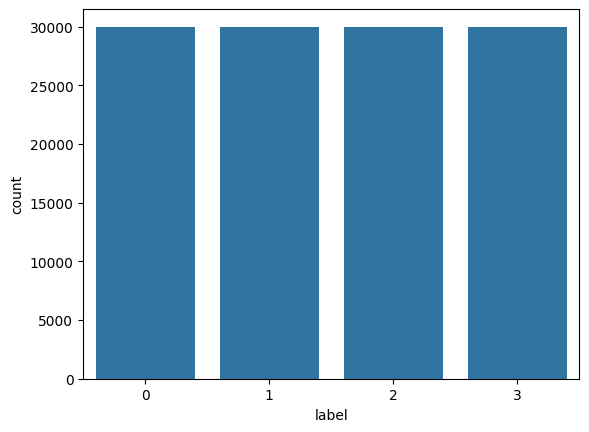

In [5]:
import seaborn as sbn
sbn.countplot(data=df_train,x="label")

## Génération d’un nuage de mots (Word Cloud) par label

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


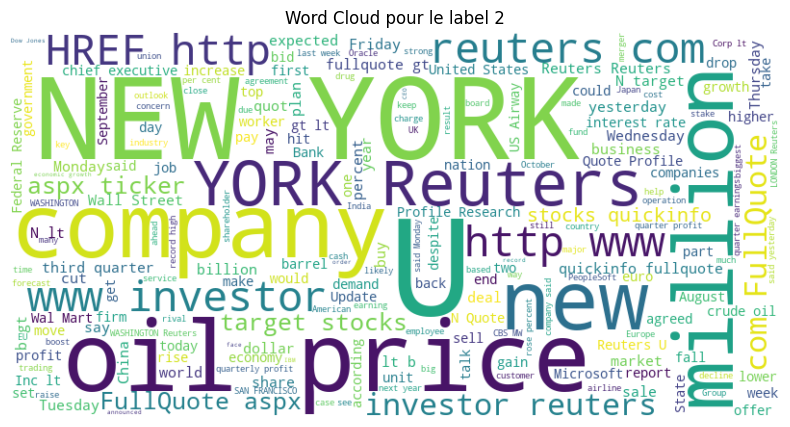

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


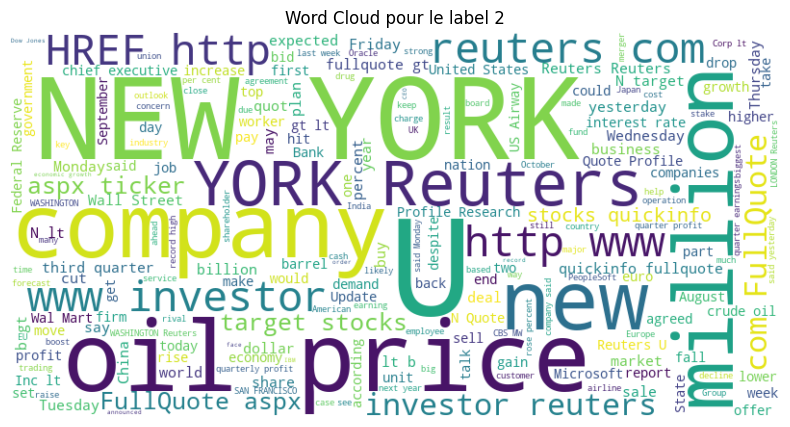

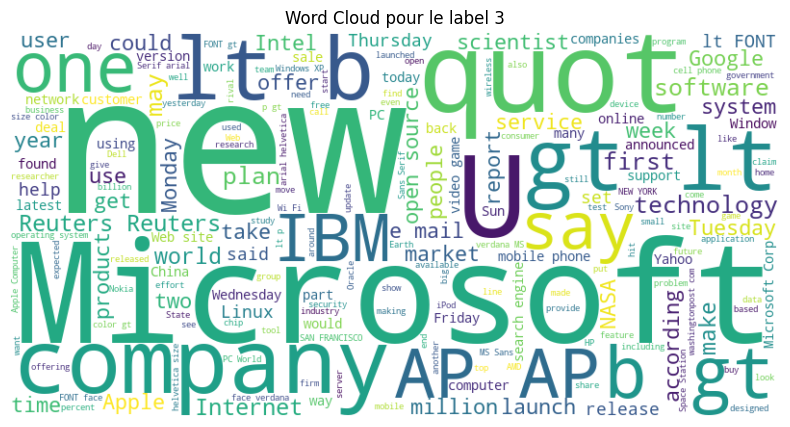

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


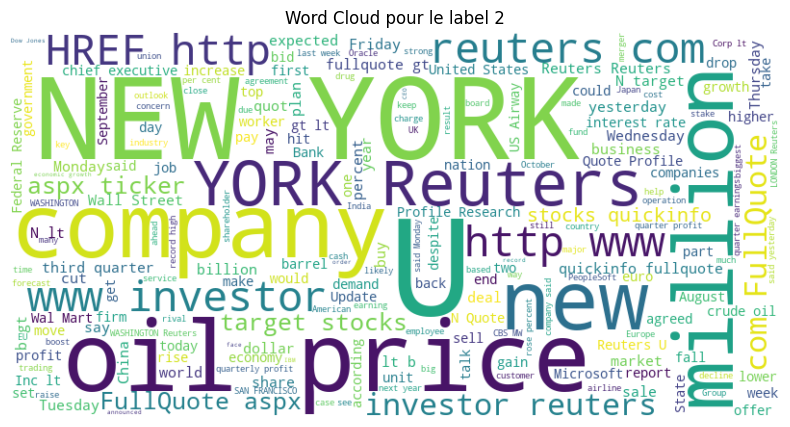

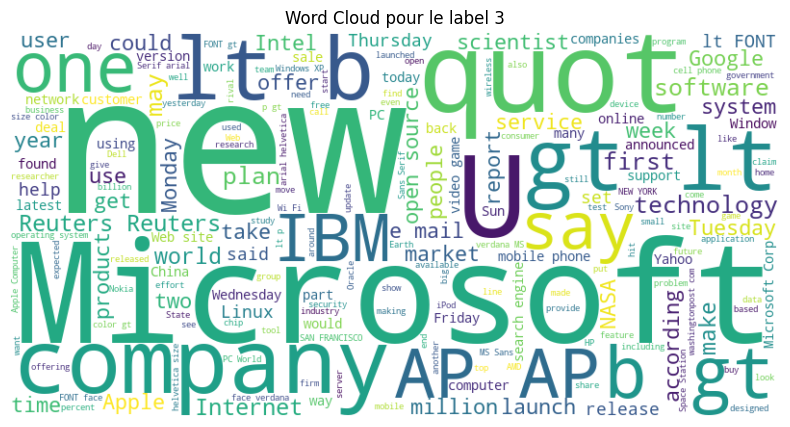

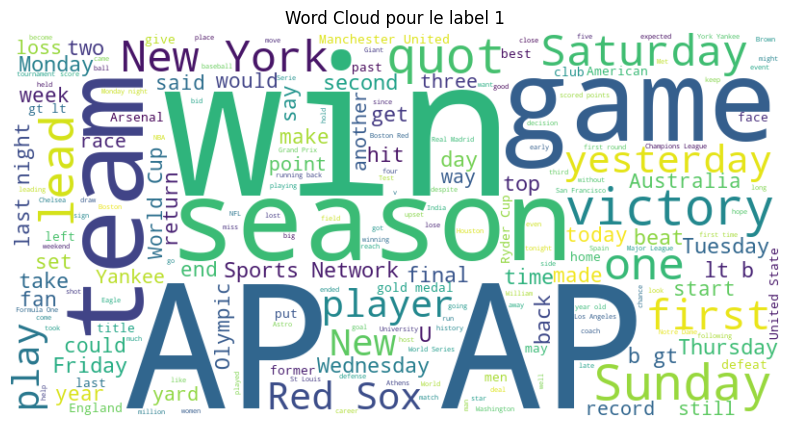

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


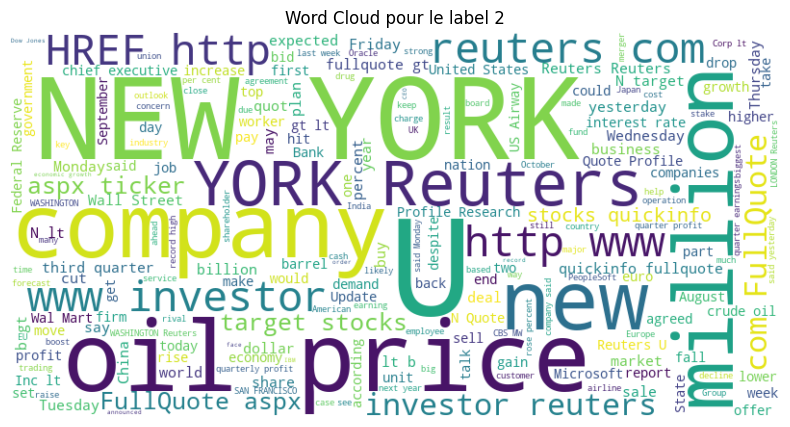

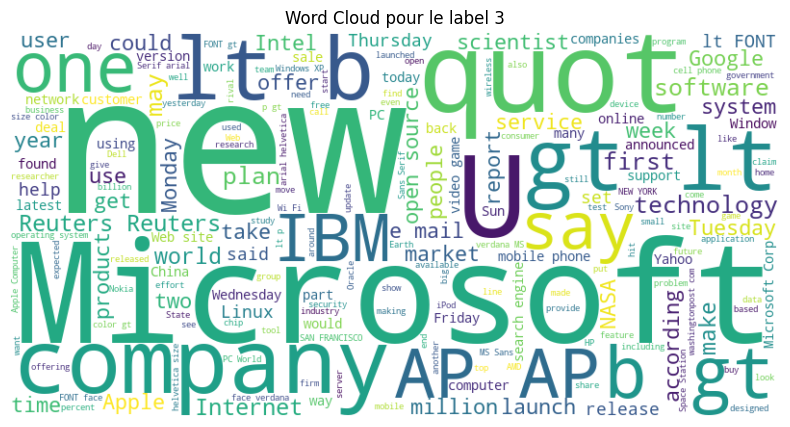

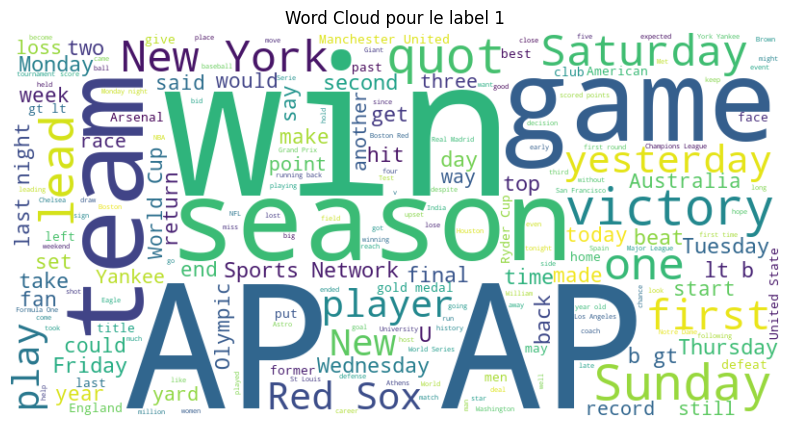

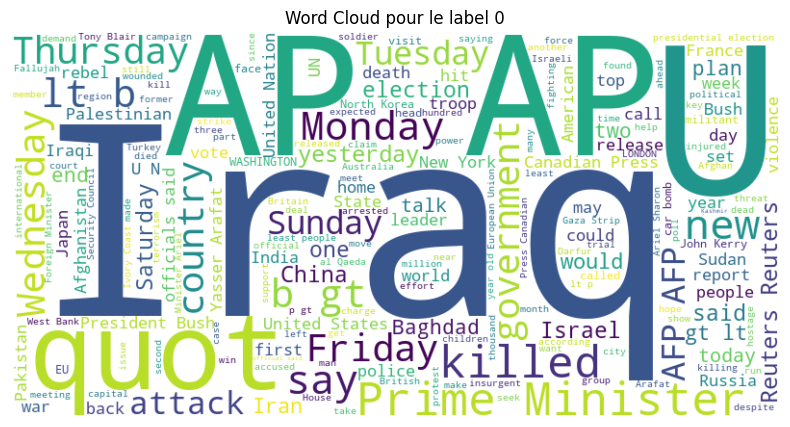

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd
import nltk
from nltk.corpus import stopwords

labels = df_train["label"].unique()
nltk.download('stopwords')

for label in labels:
    texts = df_train[df_train["label"]==label]["text"]
    combined_text = " ".join(texts)
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color="white",
        stopwords=set(stopwords.words('english'))
    ).generate(combined_text)
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud pour le label {label}")
    plt.show()

## Nettoyage du texte (suppression des caractères spéciaux)

In [7]:
df_train["text_clean"] = (df_train["text"].str.replace(r"[^a-zA-Z0-9]", " ", regex=True).str.lower())
df_train.head()

,text,label,label_text,text_clean
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business,wall st bears claw back into the black reute...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business,carlyle looks toward commercial aerospace reu...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business,oil and economy cloud stocks outlook reuters...
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business,iraq halts oil exports from main southern pipe...
4,"Oil prices soar to all-time record, posing new...",2,Business,oil prices soar to all time record posing new...


## Vérification de la version de Sentence Transformers installée

In [9]:
import sentence_transformers

print(sentence_transformers.__version__)

2.3.1


## Génération des embeddings avec le modèle Sentence Transformers

In [10]:
import pandas as pd
from sentence_transformers import SentenceTransformer

# Charger le modèle
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

train_embeddings = model.encode(df_train["text"].tolist(), batch_size=32, show_progress_bar=True)
test_embeddings  = model.encode(df_test["text"].tolist(), batch_size=32, show_progress_bar=True)

df_train["embeddings"] = [emb.tolist() for emb in train_embeddings]  
df_test["embeddings"]  = [emb.tolist() for emb in test_embeddings]

df_train["id"] = range(len(df_train))
df_test["id"]  = range(len(df_test))

print(df_train.head())


/usr/local/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Batches: 100%|██████████| 3750/3750 [40:14<00:00,  1.55it/s]  

Batches: 100%|██████████| 238/238 [02:16<00:00,  1.74it/s]



/usr/local/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Batches: 100%|██████████| 3750/3750 [40:14<00:00,  1.55it/s]  

Batches: 100%|██████████| 238/238 [02:16<00:00,  1.74it/s]



                                                text  label label_text  \
0  Wall St. Bears Claw Back Into the Black (Reute...      2   Business   
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2   Business   
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2   Business   
3  Iraq Halts Oil Exports from Main Southern Pipe...      2   Business   
4  Oil prices soar to all-time record, posing new...      2   Business   

                                          text_clean  \
0  wall st  bears claw back into the black  reute...   
1  carlyle looks toward commercial aerospace  reu...   
2  oil and economy cloud stocks  outlook  reuters...   
3  iraq halts oil exports from main southern pipe...   
4  oil prices soar to all time record  posing new...   

                                          embeddings  id  
0  [0.3068208694458008, -0.10956942290067673, 0.1...   0  
1  [-0.02877349592745304, -0.2898341715335846, -0...   1  
2  [-0.06412462145090103, -0.138511493802

## Préparation des métadonnées pour les ensembles d'entraînement et de test


In [11]:
df_train["id"] = range(len(df_train))
metadata_df = df_train[["id", "label", "embeddings"]]
print(metadata_df.head())


df_test["id"] = range(len(df_test))
metadata_df_test = df_test[["id", "label", "embeddings"]]
print(metadata_df_test.head())




   id  label                                         embeddings
0   0      2  [0.3068208694458008, -0.10956942290067673, 0.1...
1   1      2  [-0.02877349592745304, -0.2898341715335846, -0...
2   2      2  [-0.06412462145090103, -0.13851149380207062, 0...
3   3      2  [-0.0925673246383667, -0.04910768195986748, -0...
4   4      2  [-0.2649455964565277, -0.08370461314916611, 0....
   id  label                                         embeddings
0   0      2  [-0.08176779747009277, 0.5944132208824158, -0....
1   1      3  [-0.046474818140268326, 0.2387969195842743, -0...
2   2      3  [-0.3909934461116791, 0.02740189991891384, -0....
3   3      3  [-0.1957932710647583, -0.14022313058376312, 0....
4   4      3  [0.10097028315067291, 0.2581731081008911, 0.11...


## Sauvegarde des métadonnées et embeddings en fichiers CSV


In [13]:
import os

data_dir = "app/data"
os.makedirs(data_dir, exist_ok=True)

metadata_df.to_csv(f"{data_dir}/train_metadata_embeddings.csv", index=False)
metadata_df_test.to_csv(f"{data_dir}/test_metadata_embeddings.csv", index=False)



## Initialisation du client ChromaDB

In [17]:
import chromadb

chroma_dir = "/app/data/chroma"

client = chromadb.PersistentClient(path=chroma_dir)



Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


## Création des collections ChromaDB pour l'entraînement et le test


In [ ]:
train_collection = client.get_or_create_collection(name="train_collection")
test_collection  = client.get_or_create_collection(name="test_collection")
print(client.list_collections())

Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


[Collection(name=train_collection), Collection(name=test_collection)]


## Préparation des données d'entraînement pour l'insertion dans ChromaDB

In [39]:
train_ids = list(metadata_df["id"])
train_ids = [str(i) for i in metadata_df["id"]]
train_embeddings = list(metadata_df["embeddings"])
train_labels = list(metadata_df["label"])

for i in range(3):
    print(train_embeddings[i])

[0.3068208694458008, -0.10956942290067673, 0.16243787109851837, 0.1360110342502594, 0.2584889829158783, -0.026408733800053596, -0.3014993667602539, -0.4723113477230072, 0.0764557495713234, 0.01290343888103962, -0.20714765787124634, -0.10480047017335892, 0.10840656608343124, -0.1832759529352188, 0.03487575426697731, 0.24043895304203033, -0.09225405752658844, -0.1406606137752533, -0.027783306315541267, 0.1059478297829628, -0.6028493642807007, -0.324383407831192, 0.08399034291505814, 0.14879882335662842, -0.20585134625434875, 0.13915619254112244, -0.21967385709285736, 0.11555927991867065, -0.17924967408180237, -0.5047603249549866, -0.039165936410427094, 0.13665394484996796, -0.19974108040332794, 0.1269536167383194, -0.10556525737047195, 0.20061878859996796, 0.13633695244789124, 0.07084210962057114, 0.015497741289436817, 0.04147423431277275, 0.05328364297747612, 0.05444341525435448, 0.22596599161624908, 0.1407584697008133, 0.22329549491405487, -0.12207505851984024, 0.10198286175727844, -0.

## Préparation des données de test pour l'insertion dans ChromaDB

In [40]:
test_ids = list(metadata_df_test["id"])
test_ids = [str(i) for i in metadata_df_test["id"]]
test_embeddings = list(metadata_df_test["embeddings"])
test_labels = list(metadata_df_test["label"])


for i in range(3):
    print(train_embeddings[i])

[0.3068208694458008, -0.10956942290067673, 0.16243787109851837, 0.1360110342502594, 0.2584889829158783, -0.026408733800053596, -0.3014993667602539, -0.4723113477230072, 0.0764557495713234, 0.01290343888103962, -0.20714765787124634, -0.10480047017335892, 0.10840656608343124, -0.1832759529352188, 0.03487575426697731, 0.24043895304203033, -0.09225405752658844, -0.1406606137752533, -0.027783306315541267, 0.1059478297829628, -0.6028493642807007, -0.324383407831192, 0.08399034291505814, 0.14879882335662842, -0.20585134625434875, 0.13915619254112244, -0.21967385709285736, 0.11555927991867065, -0.17924967408180237, -0.5047603249549866, -0.039165936410427094, 0.13665394484996796, -0.19974108040332794, 0.1269536167383194, -0.10556525737047195, 0.20061878859996796, 0.13633695244789124, 0.07084210962057114, 0.015497741289436817, 0.04147423431277275, 0.05328364297747612, 0.05444341525435448, 0.22596599161624908, 0.1407584697008133, 0.22329549491405487, -0.12207505851984024, 0.10198286175727844, -0.

## Insertion des embeddings dans les collections ChromaDB

In [42]:
batch_size = 40000

for i in range(0, len(train_ids), batch_size):
    train_collection.add(
        ids=train_ids[i:i+batch_size],
        embeddings=train_embeddings[i:i+batch_size],
        metadatas=[{"label": label} for label in train_labels[i:i+batch_size]]
    )

batch_size_test = 40000
for i in range(0, len(test_ids), batch_size_test):
    test_collection.add(
        ids=test_ids[i:i+batch_size_test],
        embeddings=test_embeddings[i:i+batch_size_test],
        metadatas=[{"label": label} for label in test_labels[i:i+batch_size_test]]
    )


Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


## Vérification du nombre d'éléments dans les collections ChromaDB

In [43]:
print(train_collection.count())
print(test_collection.count())


120000
7600
